In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/atifaliak/youtube-comments-dataset/YoutubeCommentsDataSet.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/atifaliak/youtube-comments-dataset/YoutubeCommentsDataSet.csv")

In [3]:
df.shape

(18408, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB


In [5]:
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

Comment      0
Sentiment    0
dtype: int64

In [8]:
df.shape

(18364, 2)

In [9]:
df['Comment'].sample(5)

6667     thutmose iii is one of the most interesting fi...
4303     lol in school i literally thought i created a ...
14967    thanks a lot i had chosen computer science as ...
15809    i have both playstation and xbox and i like ho...
16016    legit tho i’m happy someone asked about hawkey...
Name: Comment, dtype: object

In [10]:
df['Sentiment'].value_counts()

Sentiment
positive    11402
neutral      4625
negative     2337
Name: count, dtype: int64

**Text Cleaning**

In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

In [12]:
df['Sentiment'] = df['Sentiment'].apply(clean_text)

**Model Training**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder

In [14]:
df.columns

Index(['Comment', 'Sentiment'], dtype='object')

In [15]:
X = df['Comment']
y = df['Sentiment']

In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    random_state = 42,
    test_size = 0.2
)

In [18]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_features=10000,
        min_df=2,
        max_df=0.9
    )),
    
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000
    ))
])

In [19]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_features=5000
    )),
    
    ('model', MultinomialNB(alpha=0.5))
])

In [20]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('model', MultinomialNB(alpha=0.5))])

In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
acc_score = accuracy_score(y_test,y_pred)
print("Accuracy Score", acc_score)

Accuracy Score 0.7075959705962429


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

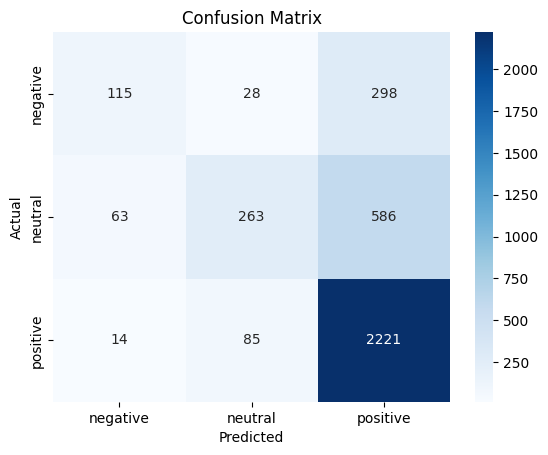

In [24]:
matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(
    matrix,
    annot=True,
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    fmt='d'
    
)

plt.xlabel('Predicted')
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
report = classification_report(y_test,y_pred, output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,2,accuracy,macro avg,weighted avg
precision,0.598958,0.699468,0.715298,0.707596,0.671241,0.697399
recall,0.260771,0.288377,0.957328,0.707596,0.502159,0.707596
f1-score,0.363349,0.408385,0.818802,0.707596,0.530179,0.662212
support,441.000000,912.000000,2320.000000,0.707596,3673.000000,3673.000000


In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [27]:
 # cross validation
kf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

cv = cross_val_score(
        pipeline,
        X,
        y_encoded,
        cv=kf,
        scoring='accuracy'
    )

In [28]:
print(cv.mean())

0.6978876207287829


In [29]:
sample = [
    "Apple pay is amazing and secure",
    "This service is terrible",
    "It is okay not bad"
]

prediction = pipeline.predict(sample)

labels = le.inverse_transform(prediction)

for text, sentiment in zip(sample, labels):
    print(f"{text} - {sentiment}")

Apple pay is amazing and secure - positive
This service is terrible - negative
It is okay not bad - positive


In [30]:
import joblib

joblib.dump(pipeline, "sentiment_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']